In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1


In [3]:
!wget http://cs.stanford.edu/people/karpathy/deepimagesent/caption_datasets.zip

URL transformed to HTTPS due to an HSTS policy
--2026-06-23 05:25:10--  https://cs.stanford.edu/people/karpathy/deepimagesent/caption_datasets.zip
Resolving cs.stanford.edu (cs.stanford.edu)... 171.64.64.64
Connecting to cs.stanford.edu (cs.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36745453 (35M) [application/zip]
Saving to: ‘caption_datasets.zip’

caption_datasets.zi 100%[===================>]  35.04M   101MB/s    in 0.3s    

2026-06-23 05:25:10 (101 MB/s) - ‘caption_datasets.zip’ saved [36745453/36745453]



In [1]:
import json
with open('files/dataset_flickr8k.json', 'r') as fb:
    data = json.load(fb)

In [2]:
from collections import Counter

train_image_paths = []
train_image_captions = []
test_image_paths = []
test_image_captions = []
word_freq = Counter()

max_len=50
for img in data['images']:
    captions = []
    for c in img['sentences']:
        word_freq.update(c['tokens'])
        if len(c['tokens']) <= max_len:
            captions.append(c['tokens'])
    if len(captions) == 0:
        continue
    path ="files/Images/"+img['filename'] 
    if img['split'] in {'train', 'val', 'restval'}:
        train_image_paths.append(path)
        train_image_captions.append(captions)
    elif img['split'] in {'test'}:
        test_image_paths.append(path)
        test_image_captions.append(captions)

In [3]:
assert len(train_image_paths)==len(train_image_captions)
assert len(test_image_paths)==len(test_image_captions)
print(f"there are {len(train_image_paths)} training images")
print(f"there are {len(test_image_paths)} test images")

there are 7000 training images
there are 1000 test images


In [4]:
# Create a dictionary to map tokens to indexes
min_word_freq=0
words = [w for w in word_freq.keys() if word_freq[w]>min_word_freq]
word2idx = {k:v + 4 for v,k in enumerate(words)}
# hard code in the special tokens
word2idx['<pad>'] = 0
word2idx['<start>'] = 1
word2idx['<end>'] = 2
word2idx['<unk>'] = 3

In [5]:
indexes=[word2idx.get(token,3) for 
         token in test_image_captions[0][0]]
print(indexes)

[12, 18, 318, 11, 12, 13, 11, 45, 30, 4, 234]


In [6]:
indexes2=[word2idx.get(token,3) for 
         token in test_image_captions[1][2]]
print(indexes2)

[4, 6, 1761, 11, 4, 713, 75, 4, 94]


In [7]:
idx2word={v:k for k, v in word2idx.items()}
tokens=[idx2word.get(idx,"<unk>") for 
         idx in indexes]
print(tokens)
print(f"there are {len(idx2word)} unique tokens")

['the', 'dogs', 'are', 'in', 'the', 'snow', 'in', 'front', 'of', 'a', 'fence']
there are 8387 unique tokens


In [8]:
tokens2=[idx2word.get(idx,"<unk>") for 
         idx in indexes2]
print(tokens2)

['a', 'dog', 'swims', 'in', 'a', 'pool', 'near', 'a', 'person']


In [9]:
import json, torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

def center_crop(img):   
    width, height = img.size   
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im

class FlickrD(Dataset):
    def __init__(self,images,captions,word2idx):
        self.images=images
        self.captions=captions
        self.word2idx=word2idx
        self._max_len = 50
        self.image_size=128
        self._image_transform = self._construct_image_transform(self.image_size)
        self._data = self._create_input_label_mappings()
        self._dataset_size = len(self._data)
        self._start_idx = 1
        self._end_idx = 2
        self._pad_idx = 0
        self._UNK_idx = 3
        self._START_token = "<start>"
        self._END_token = "<end>"
        self._PAD_token = "<pad>"
        self._UNK_token = "<unk>"       
        
    def _construct_image_transform(self, image_size):
        # ImageNet normalization statistics
        normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
        preprocessing = transforms.Compose([         
            transforms.ToTensor(),
            normalize,])
        return preprocessing
    def _load_and_process_images(self):
        # Load images
        images_raw = [center_crop(Image.open(path)).resize((self.image_size,
           self.image_size)) for path in self.images]
        # Adapt the images to CNN trained on ImageNet { PIL -> Tensor }
        image_tensors = [self._image_transform(img) for img in images_raw]
        images_processed = {img_name: img_tensor for img_name, img_tensor 
                            in zip(self.images, image_tensors)}
        return images_processed

    def _group_captions(self):
        grouped_captions = {self.images[i]:self.captions[i]
                            for i in range(len(self.images))}
        return grouped_captions
    def _create_input_label_mappings(self):
        processed_data = []
        for img, caps in self._group_captions().items():
            for cap in caps:
                pair = (img, cap)
                processed_data.append(pair)
        return processed_data    


    def _load_and_prepare_image(self, image_name):
        img_pil = center_crop(Image.open(image_name)).resize((self.image_size,
             self.image_size))
        image_tensor = self._image_transform(img_pil)
        return image_tensor


    def __len__(self):
        return self._dataset_size
    
    def __getitem__(self, index):
        # Extract the caption data
        image_id, tokens = self._data[index]
        # Load and preprocess image
        image_tensor = self._load_and_prepare_image(image_id)
        # Pad the token and label sequences
        tokens = tokens[:self._max_len]
        tokens = [token.strip().lower() for token in tokens]
        tokens = [self._START_token] + tokens + [self._END_token]
        # Extract input and target output
        input_tokens = tokens[:-1].copy()
        tgt_tokens = tokens[1:].copy()

        # Number of words in the input token
        sample_size = len(input_tokens)
        padding_size = self._max_len - sample_size

        if padding_size > 0:
            padding_vec = [self._PAD_token for _ in range(padding_size)]
            input_tokens += padding_vec.copy()
            tgt_tokens += padding_vec.copy()

        # Apply the vocabulary mapping to the input tokens
        input_tokens = [self.word2idx.get(token, self._UNK_idx)
                        for token in input_tokens]
        tgt_tokens = [self.word2idx.get(token, self._UNK_idx)
                      for token in tgt_tokens]

        input_tokens = torch.Tensor(input_tokens).long()
        tgt_tokens = torch.Tensor(tgt_tokens).long()

        # Index from which to extract the model prediction
        # Define the padding masks
        attn_mask = torch.zeros([self._max_len, ])
        attn_mask[:sample_size] = 1.0
        attn_mask = attn_mask.bool()

        return image_tensor, input_tokens, tgt_tokens, attn_mask    
    
    
    



def extract_patches(image_tensor, patch_size=16):
    # Get the dimensions of the image tensor
    bs, c, h, w = image_tensor.size()
    # Define the Unfold layer with appropriate parameters
    unfold = torch.nn.Unfold(kernel_size=patch_size,
                             stride=patch_size)
    # Apply Unfold to the image tensor
    unfolded = unfold(image_tensor)
    # Reshape the unfolded tensor to match the desired output shape
    # Output shape: BSxLxH, where L is the number of patches in each dimension
    unfolded = unfolded.transpose(1, 2).reshape(bs, -1, c * patch_size * patch_size)
    
    return unfolded


# sinusoidal positional embeds
import math
from torch import nn
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

# Define a module for attention blocks
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4, masking=True):
        super(AttentionBlock, self).__init__()
        self.masking = masking

        # Multi-head attention mechanism
        self.multihead_attn = nn.MultiheadAttention(hidden_size,
                                                    num_heads=num_heads,
                                                    batch_first=True,
                                                    dropout=0.0)

    def forward(self, x_in, kv_in, key_mask=None):
        # Apply causal masking if enabled
        if self.masking:
            bs, l, h = x_in.shape
            mask = torch.triu(torch.ones(l, l, device=x_in.device), 1).bool()
        else:
            mask = None
            
        # Perform multi-head attention operation
        return self.multihead_attn(x_in, kv_in, kv_in, attn_mask=mask, 
                                   key_padding_mask=key_mask)[0]

# Define a module for a transformer block with self-attention 
# and optional causal masking
class TransformerBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4, decoder=False, masking=True):
        super(TransformerBlock, self).__init__()
        self.decoder = decoder

        # Layer normalization for the input
        self.norm1 = nn.LayerNorm(hidden_size)
        # Self-attention mechanism
        self.attn1 = AttentionBlock(hidden_size=hidden_size, num_heads=num_heads, 
                                    masking=masking)
        
        # Layer normalization for the output of the first attention layer
        if self.decoder:
            self.norm2 = nn.LayerNorm(hidden_size)
            # Self-attention mechanism for the decoder with no masking
            self.attn2 = AttentionBlock(hidden_size=hidden_size, 
                                        num_heads=num_heads, masking=False)
        
        # Layer normalization for the output before the MLP
        self.norm_mlp = nn.LayerNorm(hidden_size)
        # Multi-layer perceptron (MLP)
        self.mlp = nn.Sequential(nn.Linear(hidden_size, hidden_size * 4),
                                 nn.ELU(),
                                 nn.Linear(hidden_size * 4, hidden_size))
                
    def forward(self, x, input_key_mask=None, cross_key_mask=None, kv_cross=None):
        # Perform self-attention operation
        x = self.attn1(x, x, key_mask=input_key_mask) + x
        x = self.norm1(x)

        # If decoder, perform additional cross-attention layer
        if self.decoder:
            x = self.attn2(x, kv_cross, key_mask=cross_key_mask) + x
            x = self.norm2(x)

        # Apply MLP and layer normalization
        x = self.mlp(x) + x
        return self.norm_mlp(x)


# Define a decoder module for the Transformer architecture
class Decoder(nn.Module):
    def __init__(self, num_emb, hidden_size=128, num_layers=3, num_heads=4):
        super(Decoder, self).__init__()
        
        # Create an embedding layer for tokens
        self.embedding = nn.Embedding(num_emb, hidden_size)
        # Initialize the embedding weights
        self.embedding.weight.data = 0.001 * self.embedding.weight.data

        # Initialize sinusoidal positional embeddings
        self.pos_emb = SinusoidalPosEmb(hidden_size)
        
        # Create multiple transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads, 
                             decoder=True) for _ in range(num_layers)
        ])
                
        # Define a linear layer for output prediction
        self.fc_out = nn.Linear(hidden_size, num_emb)
        
    def forward(self, input_seq, encoder_output, input_padding_mask=None, 
                encoder_padding_mask=None):        
        # Embed the input sequence
        input_embs = self.embedding(input_seq)
        bs, l, h = input_embs.shape

        # Add positional embeddings to the input embeddings
        seq_indx = torch.arange(l, device=input_seq.device)
        pos_emb = self.pos_emb(seq_indx).reshape(1, l, h).expand(bs, l, h)
        embs = input_embs + pos_emb
        
        # Pass the embeddings through each transformer block
        for block in self.blocks:
            embs = block(embs, 
                           input_key_mask=input_padding_mask, 
                           cross_key_mask=encoder_padding_mask, 
                           kv_cross=encoder_output)
        
        return self.fc_out(embs)

# Define an Vision Encoder module for the Transformer architecture
class VisionEncoder(nn.Module):
    def __init__(self, image_size, channels_in, patch_size=16, hidden_size=128, 
                 num_layers=3, num_heads=4):
        super(VisionEncoder, self).__init__()
        
        self.patch_size = patch_size
        self.fc_in = nn.Linear(channels_in * patch_size * patch_size, hidden_size)
        
        seq_length = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.empty(1, seq_length, 
                                                      hidden_size).normal_(std=0.02))
        
        # Create multiple transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads, 
                             decoder=False, masking=False) for _ in range(num_layers)
        ])
                
    def forward(self, image):  

        patch_seq = extract_patches(image, patch_size=self.patch_size)
        patch_emb = self.fc_in(patch_seq)

        # Add a unique embedding to each token embedding
        embs = patch_emb + self.pos_embedding
        
        # Pass the embeddings through each transformer block
        for block in self.blocks:
            embs = block(embs)
        
        return embs
    
# the Encoder-Decoder Transformer 
class VisionEncoderDecoder(nn.Module):
    def __init__(self, image_size, channels_in,
                 num_emb, patch_size=16, 
                 hidden_size=128, num_layers=(3, 3),
                 num_heads=4):
        super(VisionEncoderDecoder, self).__init__()    
        # Create an encoder and decoder with specified parameters
        self.encoder = VisionEncoder(
            image_size=image_size, channels_in=channels_in, 
            patch_size=patch_size, hidden_size=hidden_size, 
            num_layers=num_layers[0], num_heads=num_heads)
        self.decoder = Decoder(num_emb=num_emb, 
            hidden_size=hidden_size, 
            num_layers=num_layers[1], num_heads=num_heads)
    def forward(self, input_image, target_seq, padding_mask):
        # Generate padding masks for the target sequence
        bool_padding_mask = padding_mask == 0
        # Encode the input sequence
        encoded_seq = self.encoder(image=input_image)
        # Decode the target sequence using the encoded sequence
        decoded_seq = self.decoder(input_seq=target_seq, 
                         encoder_output=encoded_seq, 
                    input_padding_mask=bool_padding_mask)
        return decoded_seq

In [10]:
train_image_paths[0]

'files/Images/2513260012_03d33305cf.jpg'

In [11]:
train_image_captions[0]

[['a',
  'black',
  'dog',
  'is',
  'running',
  'after',
  'a',
  'white',
  'dog',
  'in',
  'the',
  'snow'],
 ['black', 'dog', 'chasing', 'brown', 'dog', 'through', 'snow'],
 ['two', 'dogs', 'chase', 'each', 'other', 'across', 'the', 'snowy', 'ground'],
 ['two', 'dogs', 'play', 'together', 'in', 'the', 'snow'],
 ['two',
  'dogs',
  'running',
  'through',
  'a',
  'low',
  'lying',
  'body',
  'of',
  'water']]

In [12]:
trainset=FlickrD(train_image_paths,train_image_captions,word2idx)    
testset=FlickrD(test_image_paths,test_image_captions,word2idx)   

In [13]:
trainset[0], testset[0]

((tensor([[[-0.9192, -1.0390, -1.3987,  ..., -1.1760, -0.9705, -1.2103],
           [-1.4158, -1.1932, -1.5014,  ..., -1.3987, -1.2103, -1.2103],
           [-1.4329, -1.3815, -1.6042,  ..., -1.3987, -1.1247, -1.0219],
           ...,
           [ 1.9749,  1.9407,  1.9064,  ...,  1.5810,  1.2385,  1.2899],
           [ 1.9407,  1.9064,  1.8379,  ...,  1.4783,  1.3070,  1.3070],
           [ 1.7523,  1.8722,  2.0263,  ...,  1.5297,  1.5639,  1.6153]],
  
          [[-1.0203, -1.1253, -1.3529,  ..., -1.1954, -1.0728, -1.2129],
           [-1.4055, -1.2654, -1.5105,  ..., -1.4230, -1.2479, -1.2654],
           [-1.4055, -1.3880, -1.5630,  ..., -1.4055, -1.1779, -1.1078],
           ...,
           [ 2.1485,  2.1310,  2.0784,  ...,  1.7808,  1.5007,  1.5882],
           [ 2.1310,  2.0784,  2.0084,  ...,  1.6758,  1.5532,  1.6057],
           [ 1.9209,  2.0259,  2.2010,  ...,  1.7633,  1.8333,  1.8508]],
  
          [[-0.9678, -1.0376, -1.3164,  ..., -1.1073, -0.9330, -1.1073],
           

In [55]:
import os
os.cpu_count()

30

In [76]:
from torch.utils.data import DataLoader  

train_loader = DataLoader(trainset, batch_size=384, shuffle=True, num_workers=4)     
test_loader = DataLoader(testset, batch_size=384, shuffle=True, num_workers=4)  

In [77]:
test_images,test_tokens, test_targets,test_mask=next(iter(test_loader))

In [78]:
import torch
torch.save((test_images,test_tokens),"files/tests.pt")

In [79]:
test_images.shape, test_tokens.shape

(torch.Size([384, 3, 128, 128]), torch.Size([384, 50]))

In [80]:
test_images[0], test_tokens[0]

(tensor([[[ 1.8550,  1.9235,  1.9920,  ..., -0.2684,  0.4337,  0.2111],
          [ 1.9407,  1.9407,  1.9749,  ..., -1.3302, -0.9192, -0.7993],
          [ 1.9064,  1.9578,  2.0092,  ..., -1.5528, -1.3130, -1.1760],
          ...,
          [ 1.0844,  1.0502,  0.9303,  ...,  0.9474,  1.2557,  1.0844],
          [ 1.1187,  1.1187,  1.0159,  ...,  1.2043,  1.1700,  0.9303],
          [ 0.6906,  1.1700,  1.0331,  ...,  0.9474,  1.1015,  1.1872]],
 
         [[ 2.1660,  2.2535,  2.2710,  ...,  0.1527,  0.7479,  0.3978],
          [ 2.2535,  2.2710,  2.3060,  ..., -1.0728, -0.7052, -0.6001],
          [ 2.2535,  2.2885,  2.3235,  ..., -1.4230, -1.1429, -1.0553],
          ...,
          [ 1.0980,  1.0280,  0.9230,  ...,  0.9755,  1.3256,  1.0805],
          [ 1.1856,  1.1856,  1.0805,  ...,  1.2381,  1.2031,  0.9755],
          [ 0.8004,  1.2731,  1.0630,  ...,  0.9405,  1.1331,  1.2556]],
 
         [[ 2.5354,  2.5877,  2.6226,  ...,  0.4614,  1.0539,  0.6008],
          [ 2.6051,  2.6051,

In [81]:
def extract_patches(image_tensor, patch_size=8):
    # Get the dimensions of the image tensor
    bs, c, h, w = image_tensor.size()
    # Define the Unfold layer 
    unfold = torch.nn.Unfold(kernel_size=patch_size,
                             stride=patch_size)
    # Apply Unfold to the image tensor
    unfolded = unfold(image_tensor)
    # Reshape the unfolded tensor to desired shape
    unfolded = unfolded.transpose(1, 2).reshape(bs,
                    -1, c * patch_size * patch_size)
    return unfolded

In [82]:
image=test_images[0].unsqueeze(0)
patches=extract_patches(image,patch_size=8)
print(patches.shape)

torch.Size([1, 256, 192])


In [83]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim,
                                 device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [84]:
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4, masking=True):
        super(AttentionBlock, self).__init__()
        self.masking = masking
        self.multihead_attn=nn.MultiheadAttention(hidden_size,
                                        num_heads=num_heads,
                                        batch_first=True,
                                        dropout=0.0)
    def forward(self, x_in, kv_in, key_mask=None):
        if self.masking:
            bs, l, h = x_in.shape
            mask = torch.triu(torch.ones(l, l, 
                     device=x_in.device), 1).bool()
        else:
            mask = None          
        return self.multihead_attn(x_in, kv_in, kv_in,
             attn_mask=mask,key_padding_mask=key_mask)[0]

In [85]:
class TransformerBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4, 
                 decoder=False, masking=True):
        super(TransformerBlock, self).__init__()
        self.decoder = decoder
        self.norm1 = nn.LayerNorm(hidden_size)
        self.attn1 = AttentionBlock(hidden_size=hidden_size, 
                                    num_heads=num_heads, 
                                    masking=masking)
        if self.decoder:
            self.norm2 = nn.LayerNorm(hidden_size)
            # Self-attention mechanism for the decoder with no masking
            self.attn2 = AttentionBlock(hidden_size=hidden_size, 
                            num_heads=num_heads, masking=False)
        # Layer normalization for the output before the MLP
        self.norm_mlp = nn.LayerNorm(hidden_size)
        # Multi-layer perceptron (MLP)
        self.mlp = nn.Sequential(nn.Linear(hidden_size, hidden_size * 4),
                                 nn.ELU(),
                                 nn.Linear(hidden_size * 4, hidden_size))            
    def forward(self, x, input_key_mask=None, 
                cross_key_mask=None, kv_cross=None):
        # Perform self-attention operation
        x = self.attn1(x, x, key_mask=input_key_mask) + x
        x = self.norm1(x)
        # If decoder, perform additional cross-attention layer
        if self.decoder:
            x = self.attn2(x, kv_cross,key_mask=cross_key_mask) + x
            x = self.norm2(x)
        # Apply MLP and layer normalization
        x = self.mlp(x) + x
        return self.norm_mlp(x)

In [86]:
class VisionEncoder(nn.Module):
    def __init__(self, image_size, channels_in, 
                 patch_size=16, hidden_size=128, 
                 num_layers=3, num_heads=4):
        super(VisionEncoder, self).__init__()
        self.patch_size = patch_size
        self.fc_in = nn.Linear(channels_in*patch_size*patch_size,
                               hidden_size)
        seq_length = (image_size // patch_size) ** 2
        self.pos_embedding=nn.Parameter(torch.empty(1,seq_length, 
                              hidden_size).normal_(std=0.02))      
        # Create multiple transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads, 
        decoder=False, masking=False) for _ in range(num_layers)
        ])           
    def forward(self, image):  
        bs = image.shape[0]
        patch_seq = extract_patches(image, 
                                    patch_size=self.patch_size)
        patch_emb = self.fc_in(patch_seq)
        # Add a unique embedding to each token embedding
        embs = patch_emb + self.pos_embedding
        # Pass the embeddings through each transformer block
        for block in self.blocks:
            embs = block(embs) 
        return embs

In [87]:
class Decoder(nn.Module):
    def __init__(self, num_emb, hidden_size=128, 
                 num_layers=3, num_heads=4):
        super(Decoder, self).__init__()
        # Create an embedding layer for tokens
        self.embedding = nn.Embedding(num_emb, hidden_size)
        # Initialize the embedding weights
        self.embedding.weight.data=0.001*self.embedding.weight.data
        # Initialize sinusoidal positional embeddings
        self.pos_emb = SinusoidalPosEmb(hidden_size)
        # Create multiple transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads, 
                             decoder=True) for _ in range(num_layers)
        ])        
        # Define a linear layer for output prediction
        self.fc_out = nn.Linear(hidden_size, num_emb)
        
    def forward(self, input_seq, encoder_output, 
                input_padding_mask=None, 
                encoder_padding_mask=None):        
        # Embed the input sequence
        input_embs = self.embedding(input_seq)
        bs, l, h = input_embs.shape
        # Add positional embeddings to the input embeddings
        seq_indx = torch.arange(l, device=input_seq.device)
        pos_emb = self.pos_emb(seq_indx).reshape(1,
                             l, h).expand(bs, l, h)
        embs = input_embs + pos_emb
        # Pass the embeddings through each transformer block
        for block in self.blocks:
            embs = block(embs, 
                           input_key_mask=input_padding_mask, 
                           cross_key_mask=encoder_padding_mask, 
                           kv_cross=encoder_output)       
        return self.fc_out(embs)

In [88]:
class VisionEncoderDecoder(nn.Module):
    def __init__(self, image_size, channels_in,
                 num_emb, patch_size=16, 
                 hidden_size=128, num_layers=(3, 3),
                 num_heads=4):
        super(VisionEncoderDecoder, self).__init__()    
        # Create an encoder and decoder with specified parameters
        self.encoder = VisionEncoder(
            image_size=image_size, channels_in=channels_in, 
            patch_size=patch_size, hidden_size=hidden_size, 
            num_layers=num_layers[0], num_heads=num_heads)
        self.decoder = Decoder(num_emb=num_emb, 
            hidden_size=hidden_size, 
            num_layers=num_layers[1], num_heads=num_heads)
    def forward(self, input_image, target_seq, padding_mask):
        # Generate padding masks for the target sequence
        bool_padding_mask = padding_mask == 0
        # Encode the input sequence
        encoded_seq = self.encoder(image=input_image)
        # Decode the target sequence using the encoded sequence
        decoded_seq = self.decoder(input_seq=target_seq, 
                         encoder_output=encoded_seq, 
                    input_padding_mask=bool_padding_mask)
        return decoded_seq

In [89]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# Embedding Size
hidden_size = 192
# Number of Transformer blocks for the (Encoder, Decoder)
num_layers = (6, 6)
# MultiheadAttention Heads
num_heads = 8
# Size of the patches
patch_size = 8

In [90]:
caption_model = VisionEncoderDecoder(
    image_size=128, channels_in=3, 
    num_emb=len(word2idx), patch_size=patch_size, 
    num_layers=num_layers,hidden_size=hidden_size, 
    num_heads=num_heads).to(device)

In [91]:
sum(p.numel() for p in caption_model.parameters())

9545219

In [92]:
caption_model

VisionEncoderDecoder(
  (encoder): VisionEncoder(
    (fc_in): Linear(in_features=192, out_features=192, bias=True)
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn1): AttentionBlock(
          (multihead_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
          )
        )
        (norm_mlp): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): ELU(alpha=1.0)
          (2): Linear(in_features=768, out_features=192, bias=True)
        )
      )
    )
  )
  (decoder): Decoder(
    (embedding): Embedding(8387, 192)
    (pos_emb): SinusoidalPosEmb()
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (attn1): Attention

In [93]:
# Initialize the optimizer with above parameters
from torch import nn
optimizer = torch.optim.Adam(caption_model.parameters(),
                             lr=0.0001)
scaler = torch.amp.GradScaler("cuda")
# Define the loss function
loss_fn = nn.CrossEntropyLoss(reduction="none")

In [94]:
# Let's see how many Parameters our Model has!
num_model_params = 0
for param in caption_model.parameters():
    num_model_params += param.flatten().shape[0]
print(f"This model has {num_model_params} parameters")

This model has 9545219 parameters


In [95]:
from tqdm import tqdm
# Iterate over epochs
for epoch in range(0, 50):
    # Set the model in training mode
    caption_model.train()
    eloss=0
    # Iterate over the training data loader
    for images,inputs,outputs,masks in tqdm(train_loader):
        images = images.to(device)
        tokens_in = inputs.to(device)
        padding_mask = masks.to(device)
        target_ids = outputs.to(device)
        with torch.amp.autocast("cuda"):
            # Forward pass
            pred = caption_model(images, tokens_in, 
                                 padding_mask=padding_mask)
            # Compute the loss
            loss = (loss_fn(pred.transpose(1, 2),
                            target_ids) * padding_mask).mean()        
        # Backpropagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # Log the training loss
        eloss+=loss.item()
    print(f"epoch {epoch}, loss is {eloss/len(train_loader)}")
torch.save(caption_model.state_dict(),"files/caption.pth")

100%|██████████| 92/92 [00:55<00:00,  1.67it/s]


epoch 0, loss is 1.6103137498316558


100%|██████████| 92/92 [00:54<00:00,  1.67it/s]


epoch 1, loss is 1.286281458709551


100%|██████████| 92/92 [00:57<00:00,  1.59it/s]


...

epoch 47, loss is 0.48300558717354486


100%|██████████| 92/92 [00:55<00:00,  1.65it/s]


epoch 48, loss is 0.47609191906193027


100%|██████████| 92/92 [00:57<00:00,  1.61it/s]


epoch 49, loss is 0.4684474234995635


In [113]:
from tqdm import tqdm
# Iterate over epochs
for epoch in range(50, 100):
    # Set the model in training mode
    caption_model.train()
    eloss=0
    # Iterate over the training data loader
    for images,inputs,outputs,masks in tqdm(train_loader):
        images = images.to(device)
        tokens_in = inputs.to(device)
        padding_mask = masks.to(device)
        target_ids = outputs.to(device)
        with torch.amp.autocast("cuda"):
            # Forward pass
            pred = caption_model(images, tokens_in, 
                                 padding_mask=padding_mask)
            # Compute the loss
            loss = (loss_fn(pred.transpose(1, 2),
                            target_ids) * padding_mask).mean()        
        # Backpropagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # Log the training loss
        eloss+=loss.item()
    print(f"epoch {epoch}, loss is {eloss/len(train_loader)}")
torch.save(caption_model.state_dict(),"files/caption_100.pth")

100%|██████████| 92/92 [00:52<00:00,  1.75it/s]


epoch 50, loss is 0.46200339398954227


100%|██████████| 92/92 [00:49<00:00,  1.86it/s]


epoch 51, loss is 0.4544896353846011


100%|██████████| 92/92 [00:49<00:00,  1.86it/s]


...

epoch 97, loss is 0.20434530322318492


100%|██████████| 92/92 [01:02<00:00,  1.47it/s]


epoch 98, loss is 0.20002285439683043


100%|██████████| 92/92 [01:00<00:00,  1.53it/s]


epoch 99, loss is 0.19646175448661266


In [125]:
caption_model.load_state_dict(torch.load("files/caption_100.pth",
    weights_only=True,                                     
    map_location=device))

<All keys matched successfully>

In [126]:
from tqdm import tqdm
# Iterate over epochs
for epoch in range(100, 200):
    # Set the model in training mode
    caption_model.train()
    eloss=0
    # Iterate over the training data loader
    for images,inputs,outputs,masks in tqdm(train_loader):
        images = images.to(device)
        tokens_in = inputs.to(device)
        padding_mask = masks.to(device)
        target_ids = outputs.to(device)
        with torch.amp.autocast("cuda"):
            # Forward pass
            pred = caption_model(images, tokens_in, 
                                 padding_mask=padding_mask)
            # Compute the loss
            loss = (loss_fn(pred.transpose(1, 2),
                            target_ids) * padding_mask).mean()        
        # Backpropagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # Log the training loss
        eloss+=loss.item()
    print(f"epoch {epoch}, loss is {eloss/len(train_loader)}")
torch.save(caption_model.state_dict(),"files/caption_200.pth")

100%|██████████| 92/92 [00:59<00:00,  1.55it/s]


epoch 100, loss is 0.19230180719624396


100%|██████████| 92/92 [01:00<00:00,  1.53it/s]


epoch 101, loss is 0.18893730786183607


100%|██████████| 92/92 [01:00<00:00,  1.53it/s]


...

epoch 197, loss is 0.06533684411450573


100%|██████████| 92/92 [01:04<00:00,  1.44it/s]


epoch 198, loss is 0.065563363266056


100%|██████████| 92/92 [01:03<00:00,  1.44it/s]


epoch 199, loss is 0.06624668654378342


In [129]:
from tqdm import tqdm
# Iterate over epochs
for epoch in range(200, 250):
    # Set the model in training mode
    caption_model.train()
    eloss=0
    # Iterate over the training data loader
    for images,inputs,outputs,masks in tqdm(train_loader):
        images = images.to(device)
        tokens_in = inputs.to(device)
        padding_mask = masks.to(device)
        target_ids = outputs.to(device)
        with torch.amp.autocast("cuda"):
            # Forward pass
            pred = caption_model(images, tokens_in, 
                                 padding_mask=padding_mask)
            # Compute the loss
            loss = (loss_fn(pred.transpose(1, 2),
                            target_ids) * padding_mask).mean()        
        # Backpropagation
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # Log the training loss
        eloss+=loss.item()
    print(f"epoch {epoch}, loss is {eloss/len(train_loader)}")
torch.save(caption_model.state_dict(),"files/caption_250.pth")

100%|██████████| 92/92 [01:00<00:00,  1.52it/s]


epoch 200, loss is 0.06558214808287828


100%|██████████| 92/92 [00:59<00:00,  1.56it/s]


epoch 201, loss is 0.06484931691185288


100%|██████████| 92/92 [00:58<00:00,  1.57it/s]


...

epoch 247, loss is 0.05978002771735191


100%|██████████| 92/92 [01:01<00:00,  1.49it/s]


epoch 248, loss is 0.05965964403003454


100%|██████████| 92/92 [01:02<00:00,  1.47it/s]


epoch 249, loss is 0.06143201855213746


In [130]:
def caption(image,temp=1.0):
    # Add the Start-Of-Sentence token to the prompt
    sos_token = 1 * torch.ones(1, 1).long()
    log_tokens = [sos_token]
    caption_model.eval()
    with torch.no_grad():
        # Encode the input image
        image_embedding = caption_model.encoder(image.to(device))
        # Generate the caption tokens
        for i in range(50):
            input_tokens = torch.cat(log_tokens, 1)
            # Decode input tokens into the next predicted tokens
            data_pred = caption_model.decoder(
                input_tokens.to(device),image_embedding)
            # Sample from the distribution based on temperature
            dist = Categorical(logits=data_pred[:, -1] / temp)
            next_tokens = dist.sample().reshape(1, 1)
            # Append the next predicted token to the sequence
            log_tokens.append(next_tokens.cpu())
            # Stop if the End-Of-Caption token is predicted
            if next_tokens.item() == 2:
                break  
    # Convert the list of token indices to a tensor
    pred_text = torch.cat(log_tokens, 1)
    pred_text_strings = [idx2word.get(i,"<unk>") for
                 i in pred_text[0].tolist() if i>3]
    # Join the token strings to form the predicted text
    pred_text = " ".join(pred_text_strings)
    return pred_text

In [131]:
def compare(images, captions, index, temp=1.0):
    image = images[index].unsqueeze(0)
    capi=captions[index]
    capt=[idx2word.get(i,"<unk>") for i in capi.tolist() if i>3]
    cap=" ".join(capt)
    pred=caption(image,temp=temp)
    out=torchvision.utils.make_grid(image, 1, normalize=True)
    plt.figure(figsize=(5,10),dpi=100)
    out = torchvision.utils.make_grid(image, 1, normalize=True)
    plt.imshow(out.numpy().transpose((1, 2, 0)))
    plt.title(
    f"**Original caption:\n"+cap+"\n**Generated caption:\n"+pred,
              wrap=True, loc="left", fontsize=18) 
    plt.axis("off")
    plt.show()

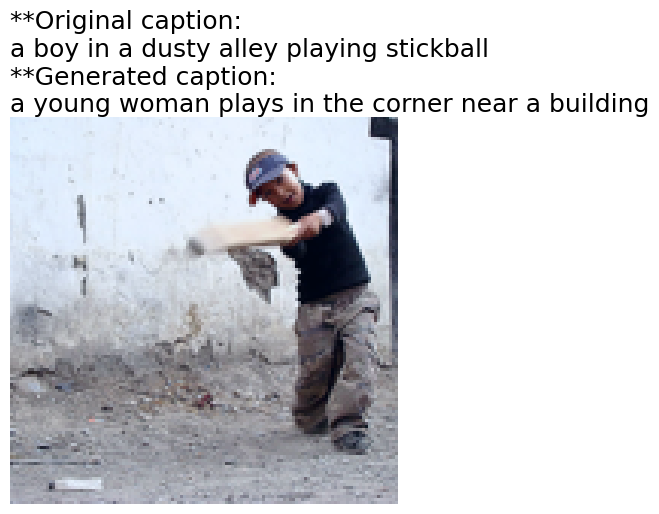

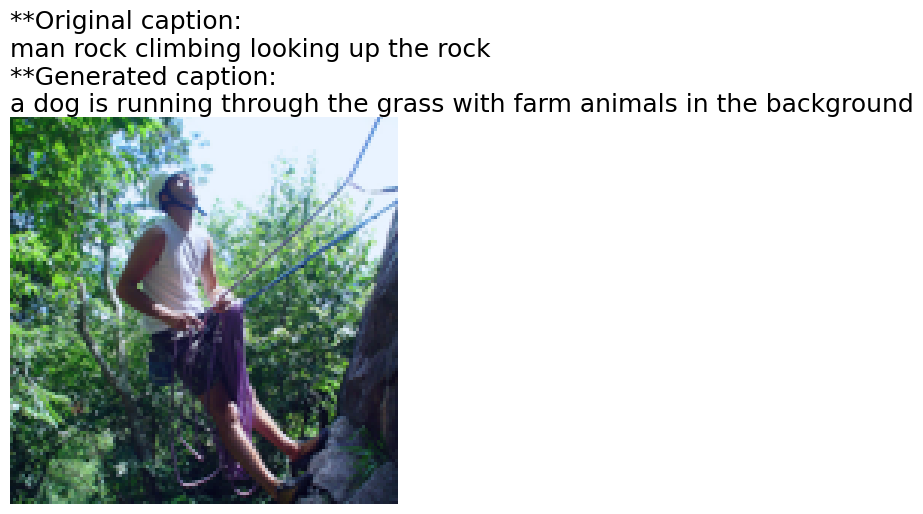

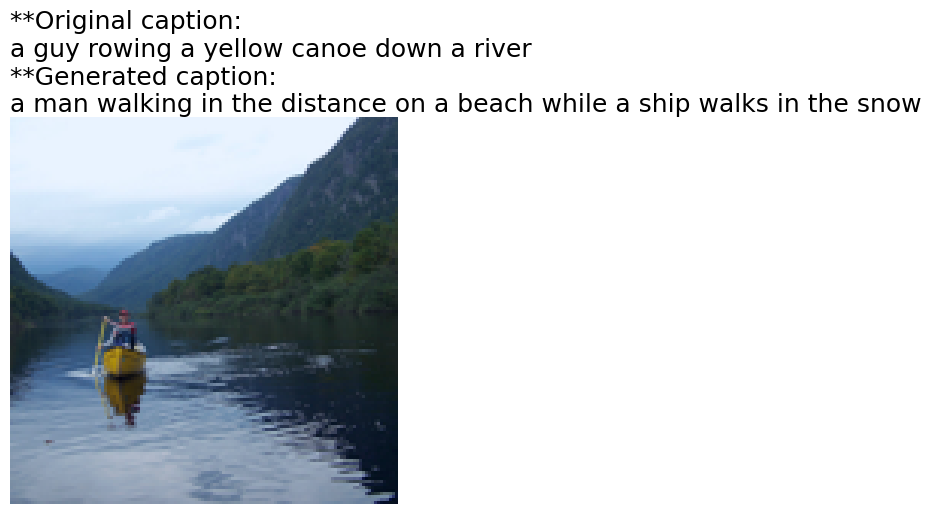

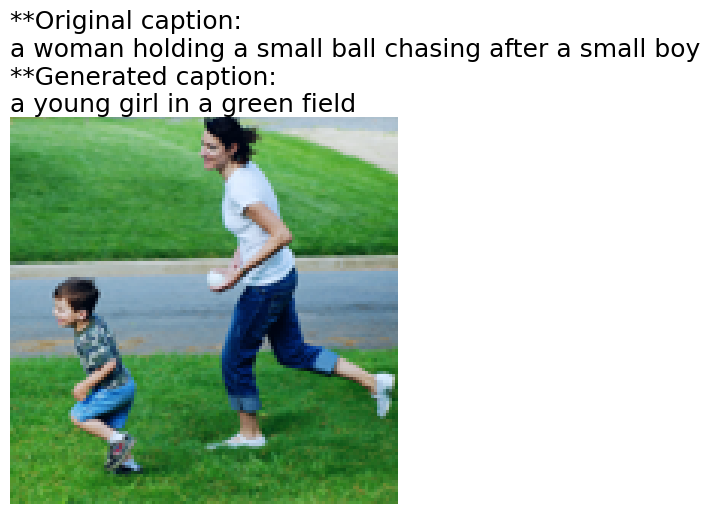

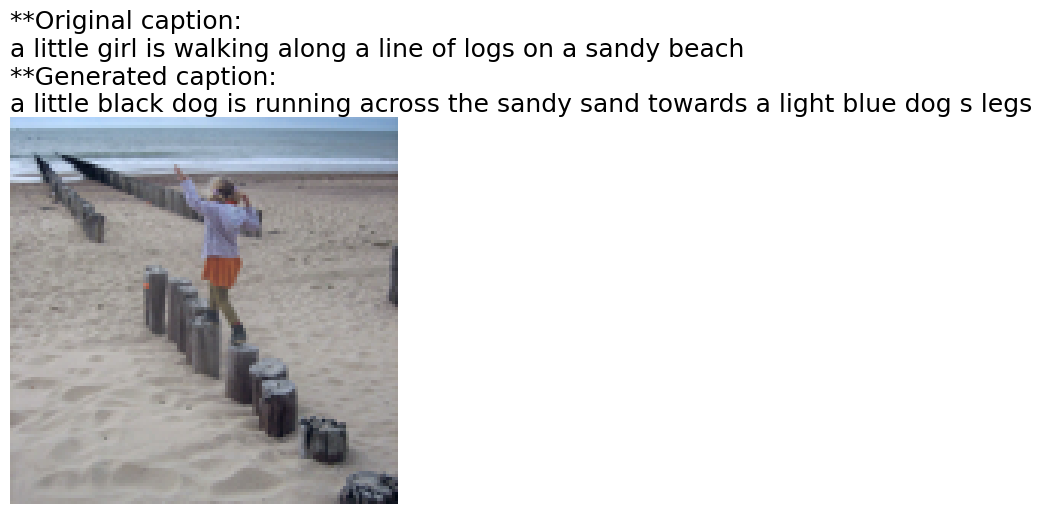

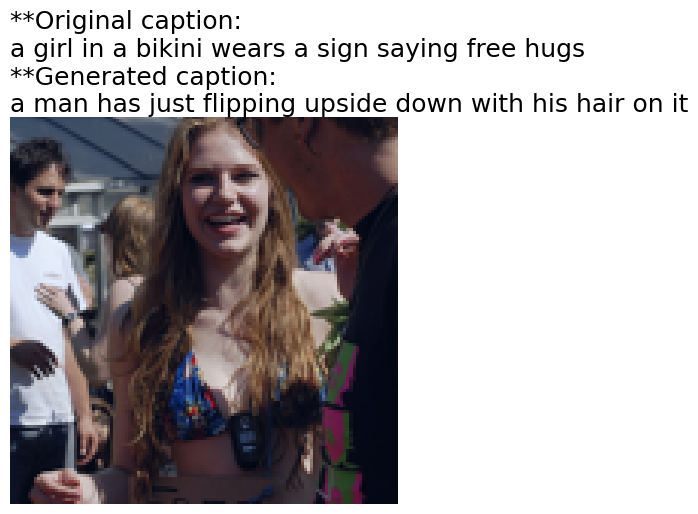

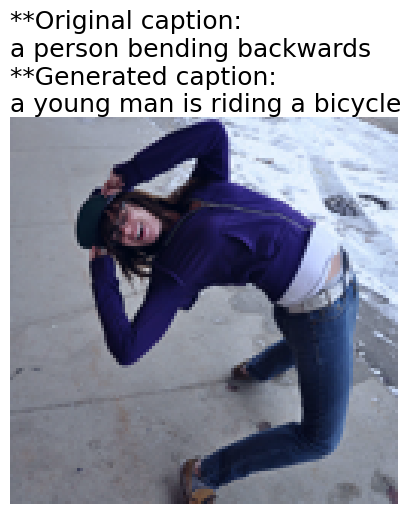

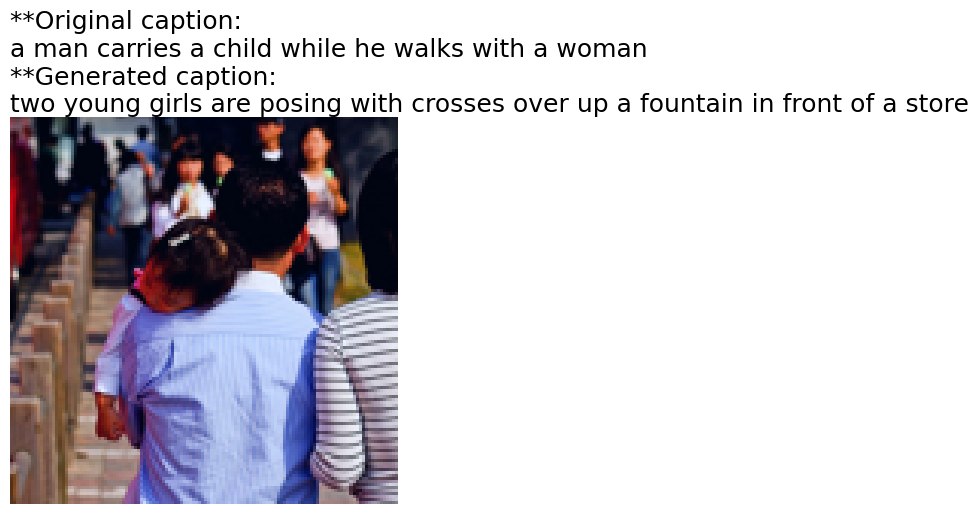

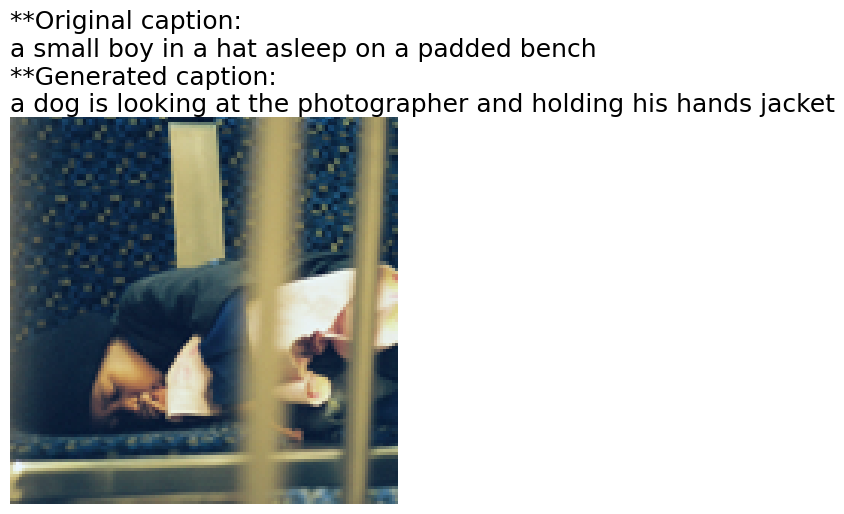

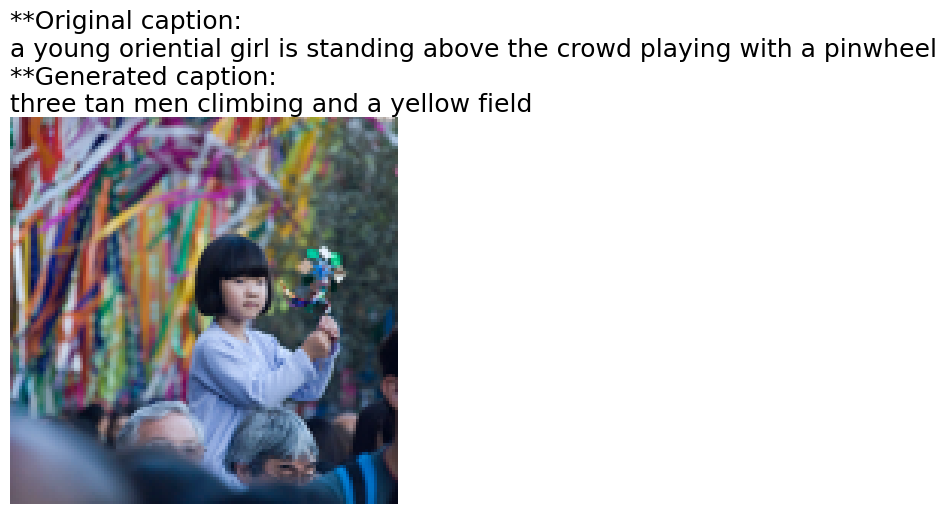

In [148]:
from torch.distributions import Categorical
import torchvision
import matplotlib.pyplot as plt

caption_model.load_state_dict(torch.load("files/caption_250.pth",
    weights_only=True,                                     
    map_location=device))
for n in range(10):
    compare(test_images,test_tokens, n, temp=0.65) 

In [100]:
test_images.shape

torch.Size([384, 3, 128, 128])

## We see that model is picking up the concepts - many times mixing up objects. Model will need more examples and more training to diversify